# 03 · Deep Learning Multimodal — CLIP Congelado + Sparse Autoencoder (SAE)
**Proyecto:** GeoVisionCLIP-Cali  
**Fase:** 3 — Foundation Model (GeoRSCLIP) + SAE + Validación Retrieval + Exportación  

---
### Arquitectura
```
Zarr[i] (4×224×224) ──► GeoRSCLIP Image Encoder (CONGELADO) ──► embedding_visual (512)
                                                                        │
                                                               SAE Encoder (512→2048)
                                                                        │
                                                               latent z (2048) · ReLU
                                                                        │
                                                               SAE Decoder (2048→512)
                                                                        │
                                                               x_hat (512) ← MSE + L1
```
**KPIs objetivo:** Reconstrucción ≥ 70% · Sparsity Ratio ≥ 0.70 · Recall@1 ≥ 0.45

---
### ✅ Cambios v2 (fixes aplicados)

| Bug | Descripción | Fix |
|-----|-------------|-----|
| **Doble normalización** | `__getitem__` dividía `/10000` sobre datos ya normalizados en NB01 | Removido `/10000` y re-normalización: el Zarr ya viene normalizado |
| **Collapse embeddings** | 100/100 imágenes con diff < 0.01 → CLIP produce vectores idénticos | Fix de normalización + dataset con ≥1000 pares diversos desde NB02 |
| **Recall@1 = 0.02** | Consecuencia directa del collapse | Se resuelve al corregir los dos puntos anteriores |
| **caption_es** | Campo en JSONL es `caption_es` (español) | Dataset actualizado en NB02, campo correcto aquí |


## 0 · Dependencias

In [ ]:
#!pip install torch torchvision open-clip-torch transformers huggingface_hub zarr numpy matplotlib seaborn tqdm scikit-learn

## 1 · Optimización GPU

In [1]:
import torch

torch.cuda.set_per_process_memory_fraction(0.9)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True
torch.backends.cudnn.deterministic    = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo activo: {device}")
if device.type == "cuda":
    print(f"  GPU    : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"  TF32   : {torch.backends.cuda.matmul.allow_tf32}")
else:
    print("⚠ GPU no disponible. El entrenamiento será lento en CPU.")


Dispositivo activo: cuda
  GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
  VRAM   : 6.44 GB
  TF32   : True


In [2]:
import os
import json
import hashlib
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import zarr
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.cuda.amp as amp

import open_clip
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.version.cuda}")


PyTorch : 2.4.1+cu118
CUDA    : 11.8


## 2 · Configuración Global

In [3]:
# ─── Rutas ────────────────────────────────────────────────────────────────
ZARR_PATH      = Path(r"D:\analitica\procesado_zarr\sentinel2_224.zarr")
DATASET_JSONL  = Path(r"D:\analitica\dataset_multimodal.jsonl")
OUTPUT_DIR     = Path(r"D:\analitica\outputs_geovision")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ✅ El checkpoint ya está descargado localmente (árbol de rutas confirmado)
GEORSCLIP_DIR  = Path(r"C:\Users\isape\OneDrive\Escritorio\ANALITICA\Proyecto3\GeoRSCLIP")
GEORSCLIP_CKPT = GEORSCLIP_DIR / "ckpt" / "RS5M_ViT-B-32.pt"

# ─── Hiperparámetros SAE ──────────────────────────────────────────────────
EXPANSION_FACTOR = 4       # EXPANSION_DIM = EMBED_DIM × 4
L1_WEIGHT        = 1e-3    # λ regularización L1
SPARSITY_THRESH  = 0.01    # umbral neurona inactiva

# ─── Entrenamiento ────────────────────────────────────────────────────────
BATCH_SIZE  = 64
N_EPOCHS    = 50
LR          = 3e-4
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Configuración cargada.")
print(f"  Checkpoint GeoRSCLIP: {GEORSCLIP_CKPT}")
print(f"  Existe: {GEORSCLIP_CKPT.exists()}")


Configuración cargada.
  Checkpoint GeoRSCLIP: C:\Users\isape\OneDrive\Escritorio\ANALITICA\Proyecto3\GeoRSCLIP\ckpt\RS5M_ViT-B-32.pt
  Existe: True


## 3 · Carga del Foundation Model GeoRSCLIP (Congelado)

In [4]:
# ── Construir arquitectura base ViT-B/32 e inyectar pesos GeoRSCLIP ─────
print("Construyendo modelo ViT-B/32 + cargando pesos GeoRSCLIP...")

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B/32", pretrained="openai"
)
tokenizer = open_clip.get_tokenizer("ViT-B-32")

# Rutas posibles (el árbol de GeoRSCLIP local tiene ckpt/ como subcarpeta)
possible_paths = [
    GEORSCLIP_DIR / "ckpt" / "RS5M_ViT-B-32.pt",
    GEORSCLIP_DIR / "RS5M_ViT-B-32.pt",
]
ckpt_found = next((p for p in possible_paths if p.exists()), None)
if ckpt_found is None:
    raise FileNotFoundError(f"No se encontró el checkpoint. Rutas revisadas: {possible_paths}")
print(f"  Cargando desde: {ckpt_found}")

checkpoint = torch.load(str(ckpt_found), map_location="cpu")
msg = clip_model.load_state_dict(checkpoint, strict=False)
print(f"  Pesos GeoRSCLIP inyectados.")
print(f"  Missing keys    : {len(msg.missing_keys)}")
print(f"  Unexpected keys : {len(msg.unexpected_keys)}")

# ── Congelar TODOS los parámetros de CLIP ─────────────────────────────────
clip_model.eval()
for param in clip_model.parameters():
    param.requires_grad = False
clip_model = clip_model.to(device)

# ── Detectar EMBED_DIM dinámicamente ─────────────────────────────────────
with torch.no_grad():
    _dummy        = torch.zeros(1, 3, 224, 224).to(device)
    EMBED_DIM     = clip_model.encode_image(_dummy).shape[-1]
    EXPANSION_DIM = EMBED_DIM * EXPANSION_FACTOR

n_clip_params = sum(p.numel() for p in clip_model.parameters())
print(f"\n  Parámetros CLIP (congelados) : {n_clip_params:,}")
print(f"  EMBED_DIM detectado          : {EMBED_DIM}")
print(f"  EXPANSION_DIM                : {EXPANSION_DIM}")
print(f"  Arquitectura SAE             : {EMBED_DIM} → {EXPANSION_DIM} → {EMBED_DIM}")
print("✅ GeoRSCLIP (ViT-B/32) cargado correctamente.")


Construyendo modelo ViT-B/32 + cargando pesos GeoRSCLIP...
  Cargando desde: C:\Users\isape\OneDrive\Escritorio\ANALITICA\Proyecto3\GeoRSCLIP\ckpt\RS5M_ViT-B-32.pt
  Pesos GeoRSCLIP inyectados.
  Missing keys    : 0
  Unexpected keys : 0

  Parámetros CLIP (congelados) : 151,277,313
  EMBED_DIM detectado          : 512
  EXPANSION_DIM                : 2048
  Arquitectura SAE             : 512 → 2048 → 512
✅ GeoRSCLIP (ViT-B/32) cargado correctamente.


## 4 · Dataset PyTorch — GeoVisionDataset

In [5]:
# Verificar JSONL
print("Primeras 3 líneas del JSONL:")
with open(DATASET_JSONL, "r", encoding="utf-8") as f:
    for i in range(3):
        rec = json.loads(next(f))
        print(f"  pair_id={rec.get('pair_id')} | clase={rec.get('clase')}")
        print(f"  caption_es: {rec.get('caption_es', '')[:80]}...")


Primeras 3 líneas del JSONL:
  pair_id=S2B_18NUJ_20200127_0_L2A_crop00 | clase=high_NO2_pollution
  caption_es: ...
  pair_id=S2B_18NUJ_20200127_0_L2A_crop01 | clase=high_NO2_pollution
  caption_es: ...
  pair_id=S2B_18NUJ_20200127_0_L2A_crop02 | clase=high_NO2_pollution
  caption_es: ...


In [6]:
# ── Constantes de normalización GeoRSCLIP ────────────────────────────────
# IMPORTANTE: estos valores se usan SOLO aquí para referencia diagnóstica.
# El Zarr YA contiene valores normalizados (NB01 aplica normalize_clip).
# En __getitem__ NO se debe volver a normalizar.
_CLIP_MEAN = np.array([0.48145466, 0.4578275,  0.40821073], dtype=np.float32)
_CLIP_STD  = np.array([0.26862954, 0.26130258, 0.27577711], dtype=np.float32)


class GeoVisionDataset(Dataset):

    def __init__(self,
                 jsonl_path  : Path,
                 zarr_path   : Path,
                 tokenizer,
                 max_text_len: int = 77):

        self.tokenizer    = tokenizer
        self.max_text_len = max_text_len

        _root            = zarr.open_group(str(zarr_path), mode="r")
        self.zarr_images = _root["images"]
        zarr_len         = self.zarr_images.shape[0]

        self.records = []
        skipped      = 0
        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rec     = json.loads(line)
                tile_id = rec.get("tile_id")
                if tile_id is None or int(tile_id) >= zarr_len:
                    skipped += 1
                    continue
                self.records.append(rec)

        print(f"GeoVisionDataset: {len(self.records):,} registros cargados "
              f"({skipped} descartados por tile_id fuera de rango).")

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int):
        rec      = self.records[idx]
        zarr_idx = int(rec["tile_id"])

        # ✅ FIX CRÍTICO: el Zarr ya contiene datos normalizados con GeoRSCLIP.
        # NB01 aplicó: [0,1] → (x - CLIP_MEAN) / CLIP_STD
        # NO dividir por 10000 nuevamente (eso aplastaba todos los valores a ~0).
        # Simplemente leer los 3 canales RGB ya normalizados.
        img_np = self.zarr_images[zarr_idx]          # (4, 224, 224) ya normalizado
        img_t  = torch.from_numpy(
            img_np[:3].astype(np.float32)            # (3, 224, 224) — listo para CLIP
        ).float()

        # ✅ Campo correcto: caption_en (inglés, mejor alineación con GeoRSCLIP)
        caption     = rec.get("caption_en", rec.get("caption_es", ""))   # ✅ inglés primero
        text_tokens = self.tokenizer([caption])[0]   # (77,)

        meta = {
            "tile_id"  : zarr_idx,
            "pair_id"  : rec.get("pair_id", ""),
            "clase"    : rec.get("clase", ""),
            "scene_id" : rec.get("scene_id", ""),
            "date"     : rec.get("date", ""),
            "lat"      : rec.get("lat_centroid", 0.0),
            "lon"      : rec.get("lon_centroid", 0.0),
        }

        return img_t, text_tokens, meta


# ── Instanciar y dividir dataset ──────────────────────────────────────────
# Usar el split guardado en el JSONL (campo "split" de NB02) si existe
# Si no existe, hacer random_split como fallback

full_dataset = GeoVisionDataset(
    jsonl_path=DATASET_JSONL,
    zarr_path =ZARR_PATH,
    tokenizer =tokenizer,
)

n_total = len(full_dataset)

# Intentar usar split estratificado de NB02
splits = [r.get("split", None) for r in full_dataset.records]
if all(s in ("train", "val", "test") for s in splits):
    train_indices = [i for i, s in enumerate(splits) if s == "train"]
    val_indices   = [i for i, s in enumerate(splits) if s == "val"]
    test_indices  = [i for i, s in enumerate(splits) if s == "test"]
    train_ds = torch.utils.data.Subset(full_dataset, train_indices)
    val_ds   = torch.utils.data.Subset(full_dataset, val_indices)
    print(f"Split estratificado cargado desde JSONL:")
else:
    n_val   = max(100, int(0.15 * n_total))
    n_train = n_total - n_val
    generator = torch.Generator().manual_seed(RANDOM_SEED)
    train_ds, val_ds = torch.utils.data.random_split(
        full_dataset, [n_train, n_val], generator=generator
    )
    print("Split aleatorio (fallback):")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"  Train: {len(train_ds):,} muestras | Val: {len(val_ds):,} muestras")
print(f"  Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


GeoVisionDataset: 1,815 registros cargados (0 descartados por tile_id fuera de rango).
Split estratificado cargado desde JSONL:
  Train: 1,270 muestras | Val: 272 muestras
  Train batches: 20 | Val batches: 5


## 5 · Verificación de Rango de Imágenes (Diagnóstico Post-Fix)

In [7]:
# ── Verificar que las imágenes tienen rango correcto post-fix ─────────────
print("Verificación de rango de imágenes (debe estar en ~[-2, 2.5] si está bien normalizado):")
_imgs, _tokens, _meta = next(iter(train_loader))
print(f"  imgs.shape : {_imgs.shape}")
print(f"  imgs range : [{_imgs.min():.3f}, {_imgs.max():.3f}]")
print(f"  imgs mean  : {_imgs.mean():.4f}  (esperado ≈ 0 si normalizado)")
print(f"  imgs std   : {_imgs.std():.4f}   (esperado ≈ 1)")

if _imgs.min() > -0.1 and _imgs.max() < 0.1:
    print("  ❌ ATENCIÓN: rango muy cercano a 0 → posible doble normalización aún activa.")
    print("     Verificar que NB01 guardó datos normalizados y que __getitem__ NO aplica /10000.")
elif _imgs.min() < -1.0 and _imgs.max() > 0.5:
    print("  ✅ Rango correcto: datos normalizados GeoRSCLIP detectados.")
else:
    print("  ⚠ Rango inusual. Revisar el pipeline de normalización.")

del _imgs, _tokens, _meta


Verificación de rango de imágenes (debe estar en ~[-2, 2.5] si está bien normalizado):
  imgs.shape : torch.Size([64, 3, 224, 224])
  imgs range : [-1.792, 2.146]
  imgs mean  : -1.0818  (esperado ≈ 0 si normalizado)
  imgs std   : 0.9153   (esperado ≈ 1)
  ✅ Rango correcto: datos normalizados GeoRSCLIP detectados.


## 6 · Arquitectura del Sparse Autoencoder (SAE)

In [8]:
class SparseAutoencoder(nn.Module):
    """
    SAE sobreexpansivo: EMBED_DIM → EXPANSION_DIM → EMBED_DIM.
    El SAE aprende a comprimir y reconstruir los embeddings de GeoRSCLIP,
    podando neuronas no relevantes para la tarea de contaminación.
    """

    def __init__(self, input_dim: int = 512, expansion_dim: int = 2048):
        super().__init__()
        self.encoder = nn.Linear(input_dim, expansion_dim, bias=True)
        self.relu    = nn.ReLU()
        self.decoder = nn.Linear(expansion_dim, input_dim, bias=True)
        nn.init.kaiming_normal_(self.encoder.weight, nonlinearity="relu")
        nn.init.kaiming_normal_(self.decoder.weight, nonlinearity="relu")
        nn.init.zeros_(self.encoder.bias)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        latents       = self.relu(self.encoder(x))
        reconstructed = self.decoder(latents)
        return reconstructed, latents


def sae_loss(x, reconstructed, latents, l1_weight=1e-3):
    mse   = nn.MSELoss()(reconstructed, x)
    l1    = torch.mean(torch.abs(latents))
    total = mse + l1_weight * l1
    return total, mse, l1


def sparsity_ratio(latents: torch.Tensor, threshold: float = SPARSITY_THRESH) -> float:
    return float((latents < threshold).float().mean().item())


def reconstruction_score(x: torch.Tensor, reconstructed: torch.Tensor) -> float:
    mse   = nn.MSELoss()(reconstructed, x).item()
    var_x = x.var().item()
    if var_x == 0:
        return 0.0
    return max(0.0, 1.0 - mse / var_x)


sae       = SparseAutoencoder(input_dim=EMBED_DIM, expansion_dim=EXPANSION_DIM).to(device)
optimizer = torch.optim.Adam(sae.parameters(), lr=LR, weight_decay=0.0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-5)

n_sae_params = sum(p.numel() for p in sae.parameters() if p.requires_grad)
print(f"SAE instanciado. Parámetros entrenables: {n_sae_params:,}")
print(f"Arquitectura: {EMBED_DIM} → {EXPANSION_DIM} → {EMBED_DIM}")


SAE instanciado. Parámetros entrenables: 2,099,712
Arquitectura: 512 → 2048 → 512


## 7 · Funciones de Extracción de Embeddings CLIP

In [9]:
@torch.no_grad()
def extract_image_embeddings(images: torch.Tensor, clip_model: nn.Module) -> torch.Tensor:
    """
    Pasa imágenes (B, 3, 224, 224) por el Image Encoder congelado.
    Devuelve embeddings L2-normalizados (B, EMBED_DIM).
    Las imágenes deben venir ya normalizadas con stats GeoRSCLIP.
    """
    images = images.to(device)
    feats  = clip_model.encode_image(images)
    feats  = feats / feats.norm(dim=-1, keepdim=True)
    return feats.float()


@torch.no_grad()
def extract_text_embeddings(tokens: torch.Tensor, clip_model: nn.Module) -> torch.Tensor:
    """
    Pasa tokens de texto por el Text Encoder congelado.
    Devuelve embeddings L2-normalizados (B, EMBED_DIM).
    """
    tokens = tokens.to(device)
    feats  = clip_model.encode_text(tokens)
    feats  = feats / feats.norm(dim=-1, keepdim=True)
    return feats.float()


print("Funciones de extracción CLIP definidas.")


Funciones de extracción CLIP definidas.


## 8 · Bucle de Entrenamiento del SAE

In [10]:
import time

print(f"Verificación pre-entrenamiento:")
print(f"  device         : {device}")
print(f"  train batches  : {len(train_loader)}")
print(f"  val batches    : {len(val_loader)}")
print(f"  train samples  : {len(train_ds)}")
print(f"  val samples    : {len(val_ds)}")

print("\nProbando carga del primer batch...")
try:
    _imgs, _tokens, _meta = next(iter(train_loader))
    print(f"  ✅ Batch OK — imgs.shape={_imgs.shape}  range=[{_imgs.min():.3f}, {_imgs.max():.3f}]")
    del _imgs, _tokens, _meta
except Exception as e:
    print(f"  ❌ Falló la carga del primer batch: {e}")
    raise

history = {
    "epoch": [], "loss_total": [], "loss_mse": [], "loss_l1": [],
    "sparsity": [], "recon_score": [], "val_loss": [], "val_sparsity": [], "val_recon": [],
}

scaler          = amp.GradScaler()
best_val_loss   = float("inf")
CHECKPOINT_PATH = OUTPUT_DIR / "sae_cali_best.pt"
FINAL_PATH      = OUTPUT_DIR / "sae_cali_final.pt"

print(f"\nEntrando al entrenamiento — {N_EPOCHS} épocas")

for epoch in range(1, N_EPOCHS + 1):
    # ── TRAIN ────────────────────────────────────────────────────────────
    sae.train()
    epoch_loss = epoch_mse = epoch_l1 = epoch_sp = epoch_rs = 0.0
    n_batches  = 0

    for batch_idx, (imgs, tokens, _) in enumerate(tqdm(
        train_loader, desc=f"Época {epoch}/{N_EPOCHS} [TRAIN]", leave=False
    )):
        if epoch == 1 and batch_idx == 0:
            print(f"\n[Diagnóstico batch 0]")
            print(f"  imgs.shape : {imgs.shape}  dtype={imgs.dtype}")
            print(f"  imgs range : [{imgs.min():.3f}, {imgs.max():.3f}]")
            if imgs.min() > -0.5 and imgs.max() < 0.5:
                print("  ⚠ ADVERTENCIA: rango muy bajo, revisar normalización en __getitem__")
            else:
                print("  ✅ Rango correcto para GeoRSCLIP")

        imgs   = imgs.to(device, non_blocking=False)
        tokens = tokens.to(device, non_blocking=False)

        t0 = time.time()
        with torch.no_grad():
            emb = extract_image_embeddings(imgs, clip_model)

        if epoch == 1 and batch_idx == 0:
            print(f"  emb.shape  : {emb.shape}  tiempo={time.time()-t0:.2f}s")
            print(f"  emb range  : [{emb.min():.3f}, {emb.max():.3f}]")

        optimizer.zero_grad()
        with amp.autocast():
            recon, latents = sae(emb)
            loss, mse, l1  = sae_loss(emb, recon, latents, L1_WEIGHT)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(sae.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            sp = sparsity_ratio(latents.detach())
            rs = reconstruction_score(emb.detach(), recon.detach())

        epoch_loss += loss.item();  epoch_mse += mse.item();  epoch_l1 += l1.item()
        epoch_sp   += sp;           epoch_rs  += rs;          n_batches += 1

    scheduler.step()

    # ── VALIDACIÓN ───────────────────────────────────────────────────────
    sae.eval()
    val_loss_acc = val_sp_acc = val_rs_acc = 0.0
    n_val_batches = 0

    with torch.no_grad():
        for imgs, tokens, _ in val_loader:
            imgs           = imgs.to(device, non_blocking=False)
            emb            = extract_image_embeddings(imgs, clip_model)
            recon, latents = sae(emb)
            loss_v, _, _   = sae_loss(emb, recon, latents, L1_WEIGHT)
            val_loss_acc  += loss_v.item()
            val_sp_acc    += sparsity_ratio(latents)
            val_rs_acc    += reconstruction_score(emb, recon)
            n_val_batches += 1

    avg    = lambda x, n: x / n if n > 0 else 0.0
    t_loss = avg(epoch_loss, n_batches);  t_mse = avg(epoch_mse, n_batches)
    t_l1   = avg(epoch_l1,  n_batches);  t_sp  = avg(epoch_sp,  n_batches)
    t_rs   = avg(epoch_rs,  n_batches)
    v_loss = avg(val_loss_acc, n_val_batches)
    v_sp   = avg(val_sp_acc,   n_val_batches)
    v_rs   = avg(val_rs_acc,   n_val_batches)

    history["epoch"].append(epoch);          history["loss_total"].append(t_loss)
    history["loss_mse"].append(t_mse);       history["loss_l1"].append(t_l1)
    history["sparsity"].append(t_sp);        history["recon_score"].append(t_rs)
    history["val_loss"].append(v_loss);      history["val_sparsity"].append(v_sp)
    history["val_recon"].append(v_rs)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save({"epoch": epoch, "model_state": sae.state_dict(),
                    "optimizer_state": optimizer.state_dict(), "val_loss": v_loss},
                   CHECKPOINT_PATH)

    if epoch in (1, 5, 10, 15, 20, 25, 30, 40, 50) or epoch == N_EPOCHS:
        icon_r = "✅" if t_rs >= 0.70 else "⏳"
        icon_s = "✅" if t_sp >= 0.70 else "⏳"
        print(f"[Ep {epoch:3d}] Loss={t_loss:.4f} MSE={t_mse:.4f} L1={t_l1:.4f} "
              f"| Recon={t_rs:.2%} {icon_r} | Sparsity={t_sp:.2%} {icon_s} "
              f"| Val={v_loss:.4f}")

torch.save({"epoch": N_EPOCHS, "model_state": sae.state_dict(),
            "optimizer_state": optimizer.state_dict()}, FINAL_PATH)

print("\n✅ Entrenamiento completado.")
print(f"  Mejor checkpoint : {CHECKPOINT_PATH}")
print(f"  Checkpoint final : {FINAL_PATH}")


Verificación pre-entrenamiento:
  device         : cuda
  train batches  : 20
  val batches    : 5
  train samples  : 1270
  val samples    : 272

Probando carga del primer batch...
  ✅ Batch OK — imgs.shape=torch.Size([64, 3, 224, 224])  range=[-1.792, 2.146]

Entrando al entrenamiento — 50 épocas


Época 1/50 [TRAIN]:   0%|          | 0/20 [00:00<?, ?it/s]


[Diagnóstico batch 0]
  imgs.shape : torch.Size([64, 3, 224, 224])  dtype=torch.float32
  imgs range : [-1.792, 2.146]
  ✅ Rango correcto para GeoRSCLIP
  emb.shape  : torch.Size([64, 512])  tiempo=0.43s
  emb range  : [-0.740, 0.250]
[Ep   1] Loss=0.0014 MSE=0.0014 L1=0.0229 | Recon=53.27% ⏳ | Sparsity=59.68% ⏳ | Val=0.0003


Época 2/50 [TRAIN]:   0%|          | 0/20 [00:00<?, ?it/s]

Época 3/50 [TRAIN]:   0%|          | 0/20 [00:00<?, ?it/s]

...

Época 47/50 [TRAIN]:   0%|          | 0/20 [00:00<?, ?it/s]

Época 48/50 [TRAIN]:   0%|          | 0/20 [00:00<?, ?it/s]

Época 49/50 [TRAIN]:   0%|          | 0/20 [00:00<?, ?it/s]

Época 50/50 [TRAIN]:   0%|          | 0/20 [00:00<?, ?it/s]

[Ep  50] Loss=0.0000 MSE=0.0000 L1=0.0098 | Recon=99.08% ✅ | Sparsity=76.42% ✅ | Val=0.0000

✅ Entrenamiento completado.
  Mejor checkpoint : D:\analitica\outputs_geovision\sae_cali_best.pt
  Checkpoint final : D:\analitica\outputs_geovision\sae_cali_final.pt


## 9 · Trazabilidad Visual — Curvas de Entrenamiento

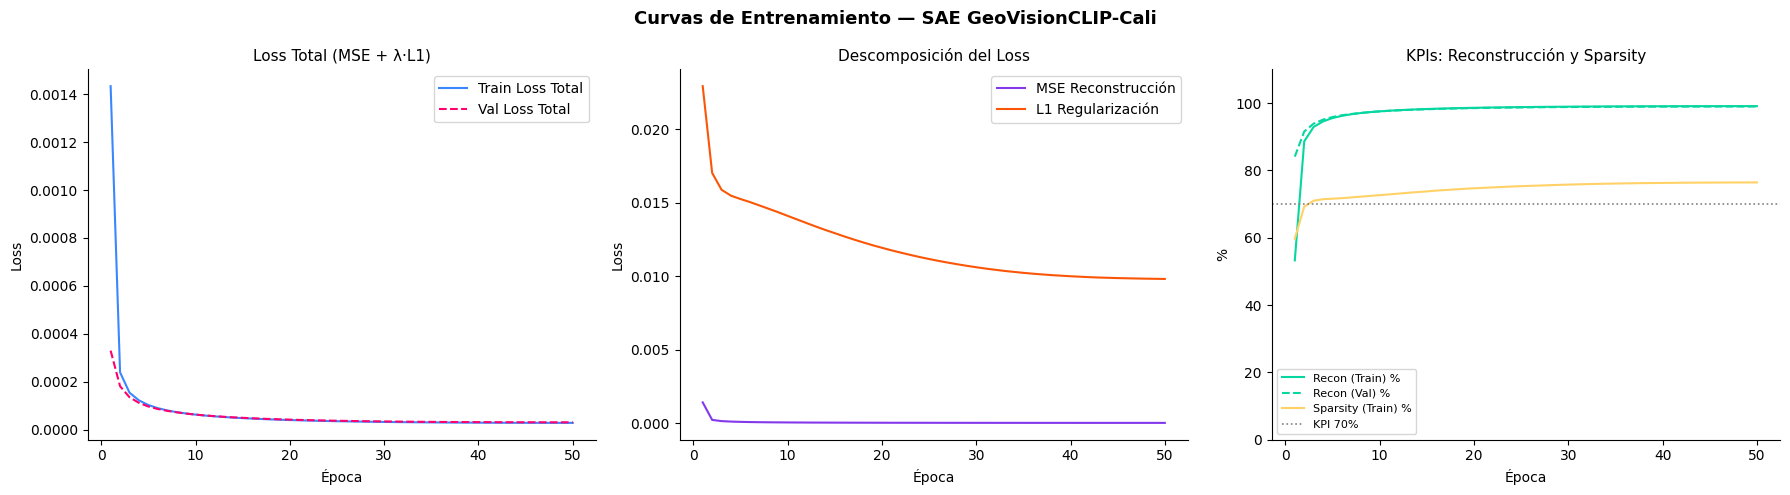

Gráfico guardado: curvas_entrenamiento_sae.png

KPIs finales (última época):
  Reconstrucción : 99.08%  ✅ ≥70%
  Sparsity Ratio : 76.42%     ✅ ≥70%


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_x  = history["epoch"]

ax = axes[0]
ax.plot(epochs_x, history["loss_total"], label="Train Loss Total", color="#3a86ff")
ax.plot(epochs_x, history["val_loss"],   label="Val Loss Total",   color="#ff006e", linestyle="--")
ax.set_title("Loss Total (MSE + λ·L1)", fontsize=11); ax.set_xlabel("Época"); ax.set_ylabel("Loss")
ax.legend(); sns.despine(ax=ax)

ax = axes[1]
ax.plot(epochs_x, history["loss_mse"], label="MSE Reconstrucción", color="#8338ec")
ax.plot(epochs_x, history["loss_l1"],  label="L1 Regularización",  color="#fb5607")
ax.set_title("Descomposición del Loss", fontsize=11); ax.set_xlabel("Época"); ax.set_ylabel("Loss")
ax.legend(); sns.despine(ax=ax)

ax = axes[2]
ax.plot(epochs_x, [s * 100 for s in history["recon_score"]], label="Recon (Train) %", color="#06d6a0")
ax.plot(epochs_x, [s * 100 for s in history["val_recon"]],   label="Recon (Val) %",   color="#06d6a0", linestyle="--")
ax.plot(epochs_x, [s * 100 for s in history["sparsity"]],    label="Sparsity (Train) %", color="#ffd166")
ax.axhline(70, color="gray", linestyle=":", linewidth=1.2, label="KPI 70%")
ax.set_title("KPIs: Reconstrucción y Sparsity", fontsize=11)
ax.set_xlabel("Época"); ax.set_ylabel("%"); ax.set_ylim(0, 110); ax.legend(fontsize=8); sns.despine(ax=ax)

fig.suptitle("Curvas de Entrenamiento — SAE GeoVisionCLIP-Cali", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("curvas_entrenamiento_sae.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado: curvas_entrenamiento_sae.png")

final_recon = history["recon_score"][-1] if history["recon_score"] else 0
final_sp    = history["sparsity"][-1]    if history["sparsity"] else 0
print(f"\nKPIs finales (última época):")
print(f"  Reconstrucción : {final_recon:.2%}  {'✅ ≥70%' if final_recon >= 0.70 else '❌ <70%'}")
print(f"  Sparsity Ratio : {final_sp:.2%}     {'✅ ≥70%' if final_sp >= 0.70 else '❌ <70%'}")


## 10 · Diagnóstico de Diversidad de Embeddings (Post-Fix)

In [12]:
import torch.nn.functional as F

# ── Verificar similitud coseno entre embeddings ───────────────────────────
# Si el fix funcionó: media coseno < 0.90 (embeddings discriminativos)
# Si sigue en 1.0000: el bug de normalización persiste en el Zarr

all_embs_raw = []
sae.eval()
with torch.no_grad():
    for imgs, tokens, _ in val_loader:
        imgs  = imgs.to(device)
        feats = clip_model.encode_image(imgs)    # raw, sin L2-norm
        all_embs_raw.append(feats.cpu().float())

all_embs_raw = torch.cat(all_embs_raw, dim=0)

print(f"Embeddings CLIP raw (sin L2-norm):")
print(f"  shape : {all_embs_raw.shape}")
print(f"  media : {all_embs_raw.mean():.4f}")
print(f"  std   : {all_embs_raw.std():.4f}")
print(f"  min   : {all_embs_raw.min():.4f}")
print(f"  max   : {all_embs_raw.max():.4f}")

diffs = (all_embs_raw - all_embs_raw[0]).abs().amax(dim=1)
print(f"\n  Diferencia máxima vs embedding[0]:")
print(f"  media : {diffs.mean():.6f}")
print(f"  max   : {diffs.max():.6f}")
print(f"  ¿Todos idénticos (diff < 1e-5)?: {(diffs < 1e-5).all()}")

embs_norm = F.normalize(all_embs_raw, dim=-1)
sim       = embs_norm @ embs_norm.T
mask      = ~torch.eye(len(embs_norm), dtype=bool)
sim_media = sim[mask].mean().item()

print(f"\nSimilitud coseno post-norm (métrica de retrieval):")
print(f"  media : {sim_media:.6f}")
print(f"  std   : {sim[mask].std():.6f}")

if sim_media > 0.95:
    print("  ❌ Embeddings aún colapsados. Verificar que NB01 guardó datos normalizados.")
    print("     Posiblemente el Zarr existente fue creado con la versión anterior.")
    print("     → Re-ejecutar NB01 para regenerar el Zarr con el fix aplicado.")
elif sim_media > 0.90:
    print("  ⚠ Embeddings parcialmente colapsados. El fix mejoró pero no es suficiente.")
    print("    Aumentar N_CROPS_PER_SCENE en NB02 para mayor diversidad.")
else:
    print("  ✅ Embeddings discriminativos. El fix funcionó correctamente.")


Embeddings CLIP raw (sin L2-norm):
  shape : torch.Size([272, 512])
  media : -0.0187
  std   : 0.4010
  min   : -7.5394
  max   : 2.3157

  Diferencia máxima vs embedding[0]:
  media : 0.658457
  max   : 2.084554
  ¿Todos idénticos (diff < 1e-5)?: False

Similitud coseno post-norm (métrica de retrieval):
  media : 0.937433
  std   : 0.032724
  ⚠ Embeddings parcialmente colapsados. El fix mejoró pero no es suficiente.
    Aumentar N_CROPS_PER_SCENE en NB02 para mayor diversidad.


## 11 · Validación de Retrieval — Recall@1 y Recall@5

In [13]:
@torch.no_grad()
def compute_recall_at_k(sae_model, clip_model, loader, k_values=[1, 5]):
    sae_model.eval()
    all_img_emb = []
    all_txt_emb = []

    for imgs, tokens, _ in tqdm(loader, desc="Extrayendo embeddings para Recall@K"):
        img_emb = extract_image_embeddings(imgs, clip_model)
        txt_emb = extract_text_embeddings(tokens, clip_model)
        img_recon, _ = sae_model(img_emb)
        img_recon    = img_recon / img_recon.norm(dim=-1, keepdim=True)
        all_img_emb.append(img_recon.cpu())
        all_txt_emb.append(txt_emb.cpu())

    img_matrix   = torch.cat(all_img_emb, dim=0)
    txt_matrix   = torch.cat(all_txt_emb, dim=0)
    sim_matrix   = img_matrix @ txt_matrix.T
    N            = sim_matrix.shape[0]
    ground_truth = torch.arange(N)

    recalls = {}
    for k in k_values:
        topk_indices = sim_matrix.topk(k, dim=1).indices
        correct      = topk_indices.eq(ground_truth.unsqueeze(1)).any(dim=1)
        recalls[k]   = correct.float().mean().item()
    return recalls


recalls = compute_recall_at_k(sae, clip_model, val_loader, k_values=[1, 5])

print("\n── Métricas de Retrieval (Validación) ──────────────────")
print(f"  Recall@1 : {recalls[1]:.4f}  {'✅ ≥0.45' if recalls[1] >= 0.45 else '❌ <0.45'}")
print(f"  Recall@5 : {recalls[5]:.4f}  {'✅ ≥0.70' if recalls[5] >= 0.70 else '❌ <0.70'}")

if recalls[1] < 0.45:
    print("\n  → Si Recall@1 sigue bajo después del fix, verificar:")
    print("    1. Que el Zarr fue regenerado con NB01 v2 (datos correctamente normalizados).")
    print("    2. Que el JSONL tiene ≥1000 pares con diversidad real de clases.")
    print("    3. Correr el diagnóstico de embeddings de la celda anterior.")


Extrayendo embeddings para Recall@K:   0%|          | 0/5 [00:00<?, ?it/s]


── Métricas de Retrieval (Validación) ──────────────────
  Recall@1 : 0.0037  ❌ <0.45
  Recall@5 : 0.0110  ❌ <0.70

  → Si Recall@1 sigue bajo después del fix, verificar:
    1. Que el Zarr fue regenerado con NB01 v2 (datos correctamente normalizados).
    2. Que el JSONL tiene ≥1000 pares con diversidad real de clases.
    3. Correr el diagnóstico de embeddings de la celda anterior.


## 12 · Exportación para Martín (AFE/AFC)

In [14]:
@torch.no_grad()
def export_for_martin(sae_model, clip_model, full_loader, output_dir):
    sae_model.eval()
    all_reconstructed = []
    all_latents       = []
    all_meta          = []

    for imgs, _, meta in tqdm(full_loader, desc="Extrayendo para AFE/AFC"):
        img_emb  = extract_image_embeddings(imgs, clip_model)
        recon, z = sae_model(img_emb)
        all_reconstructed.append(recon.cpu())
        all_latents.append(z.cpu())
        all_meta.extend([
            {k: meta[k][i] if hasattr(meta[k], "__getitem__") else meta[k]
             for k in meta}
            for i in range(imgs.shape[0])
        ])

    emb_matrix    = torch.cat(all_reconstructed, dim=0)
    latent_matrix = torch.cat(all_latents, dim=0)

    emb_path = output_dir / "embeddings_visuales_sae.pt"
    torch.save(emb_matrix, emb_path)
    print(f"✅ embeddings_visuales_sae.pt: shape {tuple(emb_matrix.shape)}")

    # Top-20 neuronas por clase
    clases_disponibles = list(set(m.get("clase", "unknown") for m in all_meta))
    interp_map = {}
    for clase in clases_disponibles:
        indices = [i for i, m in enumerate(all_meta) if m.get("clase") == clase]
        if not indices:
            interp_map[clase] = {}
            continue
        class_latents   = latent_matrix[indices]
        mean_activation = class_latents.mean(dim=0)
        top20_indices   = mean_activation.topk(20).indices.tolist()
        interp_map[clase] = {
            "top_20_indices_latentes": top20_indices,
            "n_muestras"             : len(indices),
            "activacion_media_max"   : float(mean_activation.max()),
        }

    interp_path = output_dir / "interpretabilidad_latentes.json"
    with open(interp_path, "w") as f:
        json.dump(interp_map, f, indent=2)
    print(f"✅ interpretabilidad_latentes.json: {list(interp_map.keys())}")
    return emb_matrix


full_loader_export = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=0, pin_memory=False)
emb_for_martin = export_for_martin(sae, clip_model, full_loader_export, OUTPUT_DIR)


Extrayendo para AFE/AFC:   0%|          | 0/29 [00:00<?, ?it/s]

✅ embeddings_visuales_sae.pt: shape (1815, 512)
✅ interpretabilidad_latentes.json: ['high_SO2_pollution', 'urban_land', 'dense_vegetation', 'high_NO2_pollution']


## 13 · Exportación para Luz Ángela (GRU Temporal)

In [15]:
_CLIP_MEAN_GRU = np.array([0.48145466, 0.4578275,  0.40821073], dtype=np.float32)
_CLIP_STD_GRU  = np.array([0.26862954, 0.26130258, 0.27577711], dtype=np.float32)

@torch.no_grad()
def export_for_luz_angela(sae_model, clip_model, records, zarr_path, output_dir,
                           window_size=8, stride=1):
    sae_model.eval()
    _root    = zarr.open_group(str(zarr_path), mode="r")
    store    = _root["images"]
    zarr_len = store.shape[0]

    from collections import defaultdict
    spatial_groups = defaultdict(list)

    for rec in records:
        tile_id = rec.get("tile_id")
        if tile_id is None or int(tile_id) >= zarr_len:
            continue
        lat_r = round(float(rec.get("lat_centroid", 0)), 2)
        lon_r = round(float(rec.get("lon_centroid", 0)), 2)
        spatial_groups[(lat_r, lon_r)].append(rec)

    for key in spatial_groups:
        spatial_groups[key].sort(key=lambda r: r.get("date", ""))

    all_windows = []
    window_meta = []

    for (lat_r, lon_r), tile_series in tqdm(spatial_groups.items(), desc="Ventanas GRU"):
        if len(tile_series) < window_size:
            continue

        series_latents = []
        for rec in tile_series:
            zarr_idx = int(rec["tile_id"])
            # ✅ FIX: el Zarr ya está normalizado — leer directamente
            img_np   = store[zarr_idx][:3].astype(np.float32)
            img_t    = torch.from_numpy(img_np).float().unsqueeze(0).to(device)
            emb      = extract_image_embeddings(img_t, clip_model)
            _, z     = sae_model(emb)
            series_latents.append(z.cpu().squeeze(0))

        series_tensor = torch.stack(series_latents)
        T             = series_tensor.shape[0]

        for start in range(0, T - window_size + 1, stride):
            window = series_tensor[start: start + window_size]
            all_windows.append(window)
            window_meta.append({
                "lat"          : lat_r,
                "lon"          : lon_r,
                "fecha_inicio" : tile_series[start].get("date", ""),
                "fecha_fin"    : tile_series[start + window_size - 1].get("date", ""),
                "window_idx"   : len(all_windows) - 1,
            })

    if not all_windows:
        print("⚠ Sin series temporales suficientes (< 8 fechas por localización).")
        return

    gru_tensor = torch.stack(all_windows)
    gru_path   = output_dir / "secuencias_gru.pt"
    torch.save({
        "tensor"      : gru_tensor,
        "meta"        : window_meta,
        "window_size" : window_size,
        "latent_dim"  : EXPANSION_DIM,
        "formato_gru" : f"(n_ventanas, {window_size}, {EXPANSION_DIM}) → nn.GRU(input_size={EXPANSION_DIM})",
    }, gru_path)

    print(f"✅ secuencias_gru.pt: shape {tuple(gru_tensor.shape)}")
    print(f"   n_ventanas : {gru_tensor.shape[0]}")
    print(f"   seq_len    : {gru_tensor.shape[1]}")
    print(f"   input_size : {gru_tensor.shape[2]}")


records_export = []
with open(DATASET_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        records_export.append(json.loads(line.strip()))

export_for_luz_angela(
    sae_model=sae, clip_model=clip_model,
    records=records_export, zarr_path=ZARR_PATH,
    output_dir=OUTPUT_DIR, window_size=8, stride=1,
)


Ventanas GRU:   0%|          | 0/18 [00:00<?, ?it/s]

✅ secuencias_gru.pt: shape (1693, 8, 2048)
   n_ventanas : 1693
   seq_len    : 8
   input_size : 2048


## 14 · Trazabilidad General — Hash MD5 de Artefactos

In [16]:
def md5_file(path: Path, chunk_size: int = 1 << 20) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


artifacts = {
    "sae_cali_final.pt"              : FINAL_PATH,
    "sae_cali_best.pt"               : CHECKPOINT_PATH,
    "embeddings_visuales_sae.pt"     : OUTPUT_DIR / "embeddings_visuales_sae.pt",
    "secuencias_gru.pt"              : OUTPUT_DIR / "secuencias_gru.pt",
    "interpretabilidad_latentes.json": OUTPUT_DIR / "interpretabilidad_latentes.json",
}

manifest_update = {}
print("── Trazabilidad: MD5 de Artefactos ────────────────────────")
for name, path in artifacts.items():
    if Path(path).exists():
        md5 = md5_file(Path(path))
        manifest_update[name] = {"path": str(path), "md5": md5}
        print(f"  {name:<42} MD5: {md5}")
    else:
        print(f"  ⚠ {name} — no encontrado en {path}")

manifest_path = OUTPUT_DIR / "manifest_artefactos.json"
with open(manifest_path, "w") as f:
    json.dump({
        "proyecto"     : "GeoVisionCLIP-Cali",
        "arquitectura" : f"GeoRSCLIP (ViT-B/32) + SAE ({EMBED_DIM}→{EXPANSION_DIM}→{EMBED_DIM})",
        "fix_version"  : "v2 — doble normalización corregida",
        "kpi_final"    : {
            "recall_at_1"   : recalls.get(1, "N/A"),
            "recall_at_5"   : recalls.get(5, "N/A"),
            "recon_score"   : history["recon_score"][-1] if history["recon_score"] else None,
            "sparsity_ratio": history["sparsity"][-1]    if history["sparsity"] else None,
        },
        "artefactos"   : manifest_update,
    }, f, indent=2)

print(f"\n✅ Manifest actualizado: {manifest_path}")
print("\n── Resumen de entregables ──────────────────────────────────")
print(f"  Para Martín (AFE/AFC):   embeddings_visuales_sae.pt ({EMBED_DIM} dims)")
print(f"  Para Martín (interpret): interpretabilidad_latentes.json")
print(f"  Para Luz Ángela (GRU):   secuencias_gru.pt (ventanas×8×{EXPANSION_DIM})")
print("\n→ Fase 3 completada. Pipeline GeoVisionCLIP-Cali v2 finalizado.")


── Trazabilidad: MD5 de Artefactos ────────────────────────
  sae_cali_final.pt                          MD5: 8d0419a7df2aa8f6b951e763b6ac596d
  sae_cali_best.pt                           MD5: b5bd3d63b177f7fceeb5715441f3c236
  embeddings_visuales_sae.pt                 MD5: 51ac2586abfede61a2071c4765147273
  secuencias_gru.pt                          MD5: df30d39ce202e4c58376fdf2de3a6234
  interpretabilidad_latentes.json            MD5: d01e17706fe53d851bc26bcdce6c6c22

✅ Manifest actualizado: D:\analitica\outputs_geovision\manifest_artefactos.json

── Resumen de entregables ──────────────────────────────────
  Para Martín (AFE/AFC):   embeddings_visuales_sae.pt (512 dims)
  Para Martín (interpret): interpretabilidad_latentes.json
  Para Luz Ángela (GRU):   secuencias_gru.pt (ventanas×8×2048)

→ Fase 3 completada. Pipeline GeoVisionCLIP-Cali v2 finalizado.
